# 多臂老虎机 — 探索与利用的实验

验证 `multi-armed-bandit.tex` 中的核心结论：

1. **懊悔（Regret）**：Greedy / ε-Greedy / UCB / Thompson Sampling 的累积懊悔对比；
2. **探索行为**：各算法把拉杆次数分配给最优臂的比例随时间的变化；
3. **贝叶斯视角**：Thompson Sampling 的后验分布如何随数据收敛。

输出图：
- `fig1_regret_comparison.pdf`
- `fig2_optimal_arm_selection.pdf`
- `fig3_thompson_posterior.pdf`

预计运行时间：< 1 分钟（纯 NumPy，CPU）。

In [ ]:
BREAKRL_CHAPTER = 'multi-armed-bandit'

import sys

if 'google.colab' in sys.modules:
    import runpy
    import urllib.request
    from pathlib import Path

    _setup = Path('/content/_breakrl_colab_setup.py')
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/Powfu-zwx/BreakRL/main/scripts/colab_setup.py',
        _setup,
    )
    runpy.run_path(str(_setup))['setup'](BREAKRL_CHAPTER)


In [1]:
%matplotlib inline
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# ── Academic style ──────────────────────────────────────────────
mpl.rcParams.update({
    'font.family':        'serif',
    'font.serif':         ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size':          11,
    'axes.labelsize':     12,
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.titlepad':      10,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    10,
    'legend.framealpha':  0.9,
    'legend.edgecolor':   '#CCCCCC',
    'figure.dpi':         150,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.color':         '#DDDDDD',
    'grid.linestyle':     '--',
    'grid.linewidth':     0.6,
    'lines.linewidth':    2.0,
    'savefig.bbox':       'tight',
    'pdf.fonttype':       42,
})

# Color palette (same as other chapters)
C_BLUE   = '#2166AC'
C_RED    = '#D6604D'
C_PURPLE = '#762A83'
C_GREEN  = '#4DAC26'
C_GRAY   = '#888888'

OUTDIR = '.'

print('Setup complete.')

Setup complete.


---
## Figure 1 — 累积懊悔对比

四种算法的累积懊悔 $R(T)$（20 个随机种子，阴影为 $\pm 1\sigma$）：Greedy 近似线性增长；$\varepsilon$-Greedy（$\varepsilon=0.1$）次之但仍是线性；UCB 与 Thompson Sampling 呈亚线性（$O(\log T)$）。

In [2]:
# ── 老虎机设定 ────────────────────────────────────────────────
# 10 个臂。注意臂 0 的真值 0.60 偏高且排在最前：初始各拉一次时，
# 贪心算法极易在臂 0 上“中一次奖”后被它困住，从而演示它的失败模式。
MU = np.array([0.60, 0.20, 0.40, 0.15, 0.30, 0.50, 0.25, 0.45, 0.35, 0.90])
K = len(MU)
MU_STAR = MU.max()
K_STAR  = int(MU.argmax())

print(f'K = {K} arms')
print('mu  =', np.round(MU, 2))
print(f'optimal arm k* = {K_STAR}, mu* = {MU_STAR}')

T = 2000          # 步数
N_SEEDS = 20      # 随机种子数


def run_greedy(T, seed):
    """纯贪心：先把每个臂各拉一次（否则没有任何估计），之后永远选当前估计最高的臂。"""
    rng = np.random.default_rng(seed)
    counts, rewards, est = np.zeros(K), np.zeros(K), np.zeros(K)
    actions = np.zeros(T, dtype=int)
    regret  = np.zeros(T)
    for t in range(T):
        a = t if t < K else int(np.argmax(est))
        r = float(rng.random() < MU[a])
        counts[a] += 1; rewards[a] += r
        est[a] = rewards[a] / counts[a]
        actions[t] = a
        regret[t] = MU_STAR - MU[a]
    return np.cumsum(regret), actions


def run_eps_greedy(T, seed, eps):
    """ε-贪心：以概率 ε 均匀随机探索，否则选当前估计最高的臂。"""
    rng = np.random.default_rng(seed)
    counts, rewards, est = np.zeros(K), np.zeros(K), np.zeros(K)
    actions = np.zeros(T, dtype=int)
    regret  = np.zeros(T)
    for t in range(T):
        if t < K:
            a = t
        elif rng.random() < eps:
            a = int(rng.integers(K))
        else:
            a = int(np.argmax(est))
        r = float(rng.random() < MU[a])
        counts[a] += 1; rewards[a] += r
        est[a] = rewards[a] / counts[a]
        actions[t] = a
        regret[t] = MU_STAR - MU[a]
    return np.cumsum(regret), actions


def run_decaying_eps(T, seed):
    """衰减 ε-贪心：ε_t = max(0.02, 1/(t+1))。纯 1/(t+1) 的探索总量只有 ~ln T，
    有限步数内几乎不探索（效果接近贪心）；加一个下界 ε_min 是实践中的常用做法。"""
    rng = np.random.default_rng(seed)
    counts, rewards, est = np.zeros(K), np.zeros(K), np.zeros(K)
    actions = np.zeros(T, dtype=int)
    regret  = np.zeros(T)
    for t in range(T):
        if t < K:
            a = t
        elif rng.random() < max(0.02, 1.0 / (t + 1)):
            a = int(rng.integers(K))
        else:
            a = int(np.argmax(est))
        r = float(rng.random() < MU[a])
        counts[a] += 1; rewards[a] += r
        est[a] = rewards[a] / counts[a]
        actions[t] = a
        regret[t] = MU_STAR - MU[a]
    return np.cumsum(regret), actions


def run_ucb(T, seed, c=1.0):
    """UCB1：点估计 + 置信上界 c·sqrt(log t / 2N_k)。"""
    rng = np.random.default_rng(seed)
    counts, rewards, est = np.zeros(K), np.zeros(K), np.zeros(K)
    actions = np.zeros(T, dtype=int)
    regret  = np.zeros(T)
    for t in range(T):
        if t < K:
            a = t
        else:
            ucb = est + c * np.sqrt(np.log(t + 1) / (2.0 * counts))
            a = int(np.argmax(ucb))
        r = float(rng.random() < MU[a])
        counts[a] += 1; rewards[a] += r
        est[a] = rewards[a] / counts[a]
        actions[t] = a
        regret[t] = MU_STAR - MU[a]
    return np.cumsum(regret), actions


def run_thompson(T, seed):
    """Thompson Sampling：从每个臂的后验 Beta(α, β) 采样，选采样值最大的臂。"""
    rng = np.random.default_rng(seed)
    alpha, beta = np.ones(K), np.ones(K)
    actions = np.zeros(T, dtype=int)
    regret  = np.zeros(T)
    for t in range(T):
        a = int(np.argmax(rng.beta(alpha, beta)))
        r = float(rng.random() < MU[a])
        alpha[a] += r; beta[a] += 1 - r
        actions[t] = a
        regret[t] = MU_STAR - MU[a]
    return np.cumsum(regret), actions

print('All four algorithms implemented.')

K = 10 arms
mu  = [0.6  0.2  0.4  0.15 0.3  0.5  0.25 0.45 0.35 0.9 ]
optimal arm k* = 9, mu* = 0.9
All four algorithms implemented.


In [3]:
ALGO_STYLE = {
    'Greedy':            C_GRAY,
    'ε-Greedy (ε=0.1)':  C_RED,
    'Decaying ε':        C_PURPLE,
    'UCB1':              C_BLUE,
    'Thompson':          C_GREEN,
}

algos = [
    ('Greedy',            run_greedy,        {}),
    ('ε-Greedy (ε=0.1)',  run_eps_greedy,    {'eps': 0.1}),
    ('UCB1',              run_ucb,           {}),
    ('Thompson',          run_thompson,      {}),
]

regrets = {}
for name, fn, kw in algos:
    Rs = np.stack([fn(T, s, **kw)[0] for s in range(N_SEEDS)])
    regrets[name] = Rs
    print(f'{name:18s} mean final regret = {Rs.mean(axis=0)[-1]:8.1f}')

Greedy             mean final regret =    291.4


ε-Greedy (ε=0.1)   mean final regret =    147.3


UCB1               mean final regret =     59.6


Thompson           mean final regret =     33.3


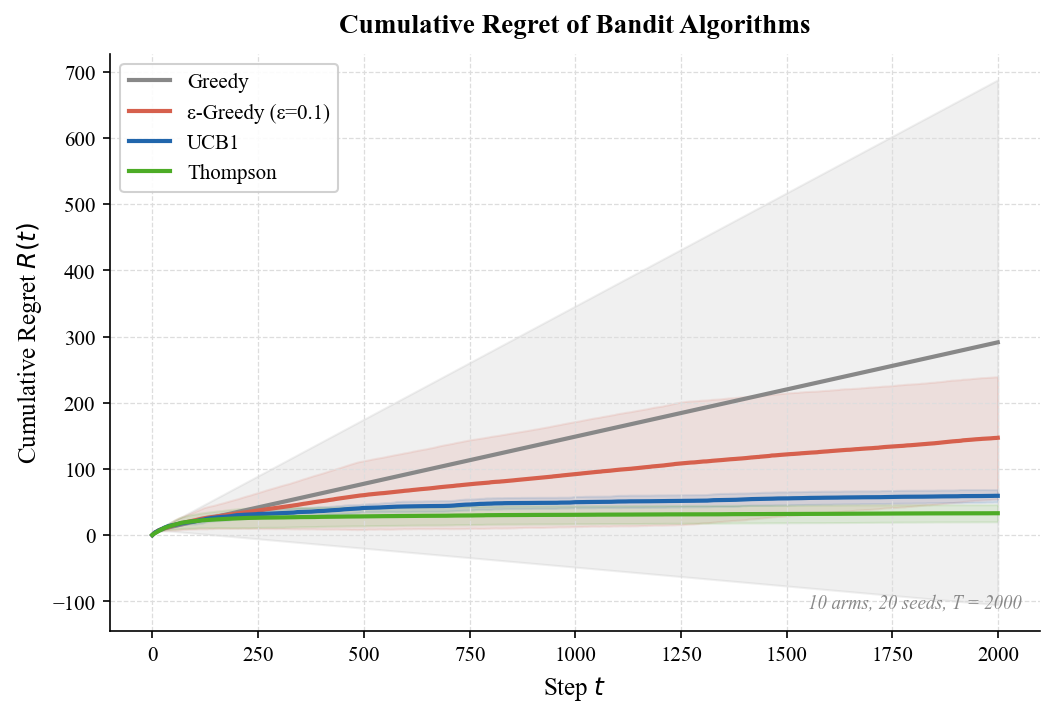

Saved fig1_regret_comparison.pdf


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(T)
for name, R in regrets.items():
    mean, std = R.mean(axis=0), R.std(axis=0)
    ax.plot(x, mean, label=name, color=ALGO_STYLE[name])
    ax.fill_between(x, mean - std, mean + std, alpha=0.12, color=ALGO_STYLE[name])

ax.set_xlabel('Step $t$')
ax.set_ylabel('Cumulative Regret $R(t)$')
ax.set_title('Cumulative Regret of Bandit Algorithms')
ax.legend(loc='upper left')
ax.text(0.98, 0.04,
        f'{K} arms, {N_SEEDS} seeds, T = {T}',
        transform=ax.transAxes, ha='right', fontsize=9, color=C_GRAY, style='italic')
fig.savefig(f'{OUTDIR}/fig1_regret_comparison.pdf', bbox_inches='tight')
plt.show()

print('Saved fig1_regret_comparison.pdf')

---
## Figure 2 — 最优臂被选中的比例（探索 vs 利用）

把“当前步是否在拉最优臂”看作成功事件，做滑动平均，就得到每一步附近选择最优臂的频率。

- **Greedy**：锁定单个臂，靠运气决定是否锁中最优臂——本例约 3 成种子被次优臂“困死”；
- **ε-Greedy**：探索概率恒定，最优臂比例收敛到 $1-\varepsilon$ 附近，永远差一口；
- **Decaying ε**：探索概率随时间衰减（此处为 $\varepsilon_t=\max(0.02,\frac{1}{t+1})$），比例缓慢爬向 1；
  注意纯 $\frac{1}{t}$ 的探索总量只有 $\sim\ln T$，有限步数内几乎不探索——衰减的“常数”很关键；
- **UCB / Thompson**：用“不确定性驱动”的探索，比例最快逼近 1。

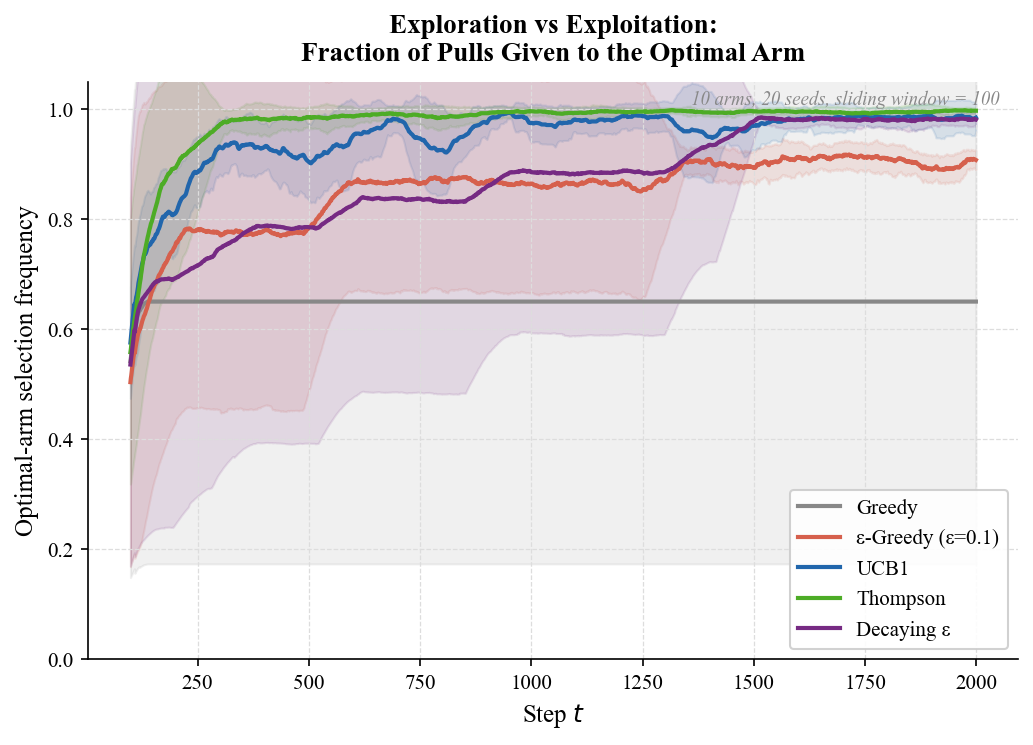

Saved fig2_optimal_arm_selection.pdf


In [5]:
WINDOW = 100
fracs = {}
for name, fn, kw in algos + [('Decaying ε', run_decaying_eps, {})]:
    acts = np.stack([fn(T, s, **kw)[1] for s in range(N_SEEDS)])
    is_opt = (acts == K_STAR).astype(float)
    kernel = np.ones(WINDOW) / WINDOW
    fracs[name] = np.stack([np.convolve(row, kernel, mode='valid') for row in is_opt])

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(WINDOW - 1, T)
for name, F in fracs.items():
    mean, std = F.mean(axis=0), F.std(axis=0)
    ax.plot(x, mean, label=name, color=ALGO_STYLE[name])
    ax.fill_between(x, mean - std, mean + std, alpha=0.12, color=ALGO_STYLE[name])

ax.set_xlabel('Step $t$')
ax.set_ylabel('Optimal-arm selection frequency')
ax.set_title('Exploration vs Exploitation:\nFraction of Pulls Given to the Optimal Arm')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.text(0.98, 0.96,
        f'{K} arms, {N_SEEDS} seeds, sliding window = {WINDOW}',
        transform=ax.transAxes, ha='right', fontsize=9, color=C_GRAY, style='italic')
fig.savefig(f'{OUTDIR}/fig2_optimal_arm_selection.pdf', bbox_inches='tight')
plt.show()

print('Saved fig2_optimal_arm_selection.pdf')

---
## Figure 3 — Thompson Sampling 的后验演化

每个臂的后验是 $\text{Beta}(\alpha_k, \beta_k)$。数据越多，分布越窄、越靠近真实 $\mu_k$；
被冷落的臂（比如真值 0.25 的臂 6）后验长期保持“宽”的形态——这正是 Thompson 采样
“用后验宽度驱动探索”的来源。

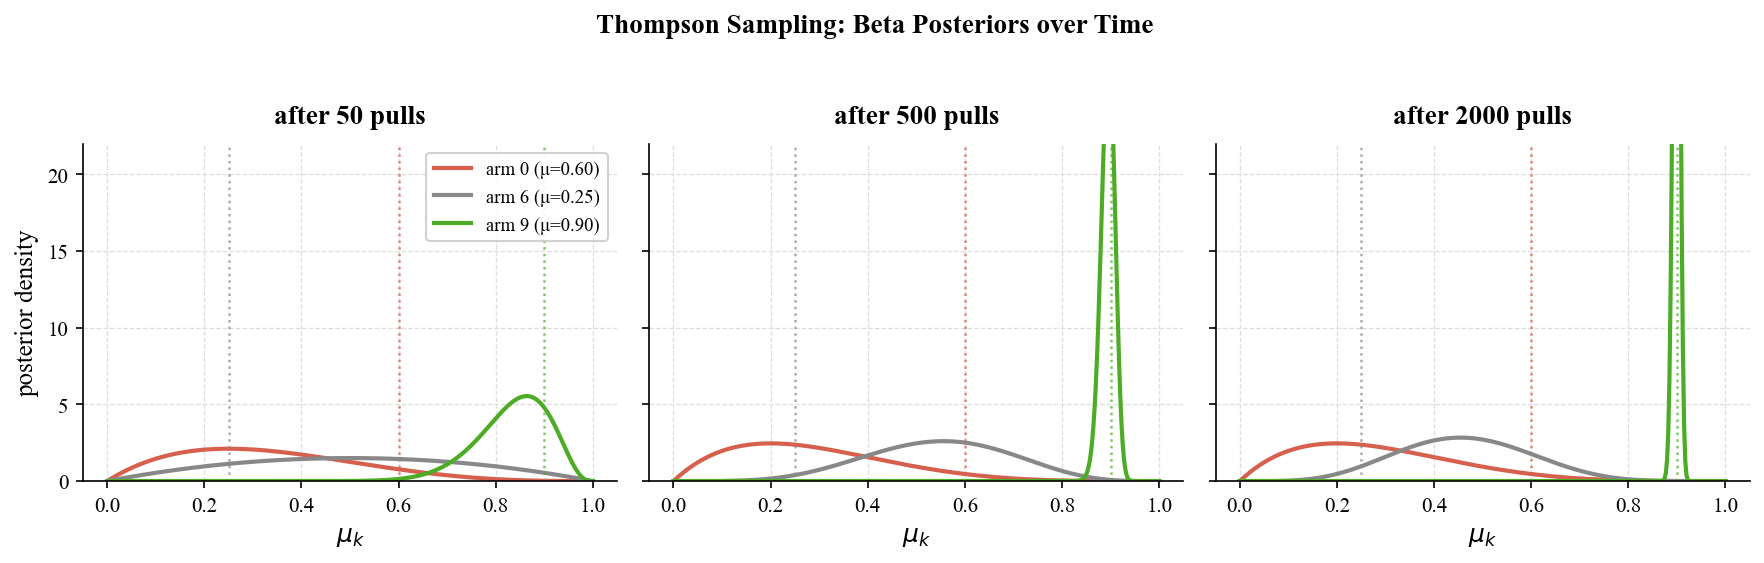

Saved fig3_thompson_posterior.pdf


In [6]:
rng = np.random.default_rng(42)
alpha, beta = np.ones(K), np.ones(K)
checkpoints = {}
for t in range(T):
    a = int(np.argmax(rng.beta(alpha, beta)))
    r = float(rng.random() < MU[a])
    alpha[a] += r; beta[a] += 1 - r
    if (t + 1) in (50, 500, 2000):
        checkpoints[t + 1] = (alpha.copy(), beta.copy())


def beta_pdf(x, a, b):
    y = np.power(x, a - 1.0) * np.power(1.0 - x, b - 1.0)
    return y / (y.sum() * (x[1] - x[0]))


x = np.linspace(0, 1, 400)
ARMS = [0, 6, K_STAR]            # 被高估的次优臂、被冷落的臂、最优臂
ARMS_LABEL = [f'arm {i} (μ={MU[i]:.2f})' for i in ARMS]
ARMS_COLOR = [C_RED, C_GRAY, C_GREEN]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax_i, (t, (a_, b_)) in enumerate(checkpoints.items()):
    ax = axes[ax_i]
    for arm, label, color in zip(ARMS, ARMS_LABEL, ARMS_COLOR):
        pdf = beta_pdf(x, a_[arm], b_[arm])
        ax.plot(x, pdf, label=label, color=color)
        ax.axvline(MU[arm], color=color, linestyle=':', linewidth=1.2, alpha=0.7)
    ax.set_title(f'after {t} pulls')
    ax.set_xlabel('$\\mu_k$')
    ax.set_ylim(0, 22)
axes[0].set_ylabel('posterior density')
axes[0].legend(loc='upper right', fontsize=9)
fig.suptitle('Thompson Sampling: Beta Posteriors over Time', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(f'{OUTDIR}/fig3_thompson_posterior.pdf', bbox_inches='tight')
plt.show()

print('Saved fig3_thompson_posterior.pdf')

## 小结

- **Greedy** 的线性懊悔来自“被早期好运困住”：它不做任何有意的探索；
- **ε-Greedy** 用恒定概率随机探索，懊悔仍线性，只是斜率变小；
- **UCB** 与 **Thompson** 的探索是“不确定性驱动”的：把探索集中到最不确定/最有希望的臂上，懊悔为亚线性（$O(\log T)$）；
- **Decaying ε**（本实验为 $\varepsilon_t=\max(0.02,\frac{1}{t+1})$）比恒定 ε 好，但下界使探索永不消失——严格的对数界需要探索概率真正衰减（见正文对衰减常数的讨论）。

In [7]:
print('All figures saved:')
print('  fig1_regret_comparison.pdf')
print('  fig2_optimal_arm_selection.pdf')
print('  fig3_thompson_posterior.pdf')

All figures saved:
  fig1_regret_comparison.pdf
  fig2_optimal_arm_selection.pdf
  fig3_thompson_posterior.pdf
